# processing large ensembles

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
# import matplotlib.pyplot as plt
# from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
# import matplotlib as mpl
# import matplotlib.ticker as mticker
import netCDF4
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from cartopy.util import add_cyclic_point
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
# from dask.distributed import Client
# client = Client(n_workers=4, threads_per_worker=2)
# client

In [4]:
from scipy import stats

In [5]:
# mpl.rcParams['font.family'] = 'Droid Sans'
# mpl.rcParams['font.size'] = 12
# # Edit axes parameters
# mpl.rcParams['axes.linewidth'] = 1.5
# # Tick properties
# mpl.rcParams['xtick.major.size'] = 5
# mpl.rcParams['xtick.minor.size'] = 3
# mpl.rcParams['xtick.major.width'] = 1
# mpl.rcParams['xtick.direction'] = 'out'
# mpl.rcParams['ytick.major.size'] = 5
# mpl.rcParams['ytick.minor.size'] = 3
# mpl.rcParams['ytick.major.width'] = 1
# mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [6]:
from functions import preproc_funcs as funcs

In [7]:
from functions import xr_lowess

In [8]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x_copy = x.copy()
    res = STL(x_copy, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [9]:
import glob
import multiprocessing as mp

In [10]:
# Function to find the first file in each model's r1* directory
def find_all_files(pattern):
    all_paths = glob.glob(pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        # model_identifier = path_parts[7] + '_' + path_parts[9][:-1]
        model_identifier = path_parts[8] + '_' + path_parts[10][:-1]
        if model_identifier not in model_files:
            model_files[model_identifier] = '/'.join(path_parts[:-1]) + '/*.nc'  # Store only the first file for each model
    return model_files


# Function to find the first file in each model's r1* directory
def find_all_files_extended(pattern):
    all_paths = glob.glob(pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        model_identifier = path_parts[8] + '_' + path_parts[10][:-1]
        if model_identifier not in model_files:
            model_files[model_identifier] = '/'.join(path_parts[:-1]) + '/*.nc'  # Store only the first file for each model
    return model_files



## find the files for a single model

In [11]:
model = 'ACCESS-ESM1-5'

In [12]:
ts_pattern_hist = f'/g/data/lp01/CMIP6/CMIP/*/{model}/historical/*/Amon/ts/gr1.5/*/*.nc'
ts_pattern_ssp5 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/ts/gr1.5/*/*.nc'
ts_pattern_ssp3 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/ts/gr1.5/*/*.nc'
ts_pattern_ssp2 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/ts/gr1.5/*/*.nc'
ts_pattern_ssp1 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/ts/gr1.5/*/*.nc'


In [13]:
co2_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/co2/gn/latest/*.nc'
co2_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/co2/gn/*/*.nc'
co2_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/co2/gn/*/*.nc'
co2_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/co2/gn/*/*.nc'
co2_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/co2/gn/*/*.nc'


In [14]:
pr_pattern_hist = f'/g/data/lp01/CMIP6/CMIP/*/{model}/historical/*/Amon/pr/gr1.5/*/*.nc'
pr_pattern_ssp5 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/pr/gr1.5/*/*.nc'
pr_pattern_ssp3 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/pr/gr1.5/*/*.nc'
pr_pattern_ssp2 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/pr/gr1.5/*/*.nc'
pr_pattern_ssp1 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/pr/gr1.5/*/*.nc'


In [15]:
ts_pattern_ssp5o_ext = f'/g/data/*/*/CMIP6/ScenarioMIP/*/{model}/ssp534-over/*/Amon/ts/gn/*/*.nc'

In [16]:
pr_pattern_ssp5o_ext = f'/g/data/*/*/CMIP6/ScenarioMIP/*/{model}/ssp534-over/*/Amon/pr/gn/*/*.nc'

In [17]:
psl_pattern_hist = f'/g/data/lp01/CMIP6/CMIP/*/{model}/historical/*/Amon/psl/gr1.5/*/*.nc'
psl_pattern_ssp5 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/psl/gr1.5/*/*.nc'
psl_pattern_ssp3 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/psl/gr1.5/*/*.nc'
psl_pattern_ssp2 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/psl/gr1.5/*/*.nc'
psl_pattern_ssp1 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/psl/gr1.5/*/*.nc'


In [18]:
pres_pattern_hist = f'/g/data/lp01/CMIP6/CMIP/*/{model}/historical/*/Amon/psl/gr1.5/*/*.nc'
pres_pattern_ssp5 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/psl/gr1.5/*/*.nc'
pres_pattern_ssp3 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/psl/gr1.5/*/*.nc'
pres_pattern_ssp2 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/psl/gr1.5/*/*.nc'
pres_pattern_ssp1 = f'/g/data/lp01/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/psl/gr1.5/*/*.nc'


In [19]:
uas_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/uas/gn/latest/*.nc'
uas_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/uas/gn/*/*.nc'
uas_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/uas/gn/*/*.nc'
uas_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/uas/gn/*/*.nc'
uas_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/uas/gn/*/*.nc'


In [20]:
vas_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/vas/gn/latest/*.nc'
vas_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/vas/gn/*/*.nc'
vas_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/vas/gn/*/*.nc'
vas_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/vas/gn/*/*.nc'
vas_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/vas/gn/*/*.nc'


In [21]:
tauu_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/tauu/gn/latest/*.nc'
tauu_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/tauu/gn/*/*.nc'
tauu_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/tauu/gn/*/*.nc'
tauu_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/tauu/gn/*/*.nc'
tauu_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/tauu/gn/*/*.nc'


In [22]:
rsdt_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/rsdt/gn/latest/*.nc'
rsdt_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/rsdt/gn/*/*.nc'
rsdt_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/rsdt/gn/*/*.nc'
rsdt_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/rsdt/gn/*/*.nc'
rsdt_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/rsdt/gn/*/*.nc'


In [23]:
rsut_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/rsut/gn/latest/*.nc'
rsut_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/rsut/gn/*/*.nc'
rsut_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/rsut/gn/*/*.nc'
rsut_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/rsut/gn/*/*.nc'
rsut_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/rsut/gn/*/*.nc'


In [24]:
rlut_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/rlut/gn/latest/*.nc'
rlut_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/rlut/gn/*/*.nc'
rlut_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/rlut/gn/*/*.nc'
rlut_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/rlut/gn/*/*.nc'
rlut_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/rlut/gn/*/*.nc'


In [25]:
rsds_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/rsds/gn/latest/*.nc'
rsds_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/rsds/gn/*/*.nc'
rsds_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/rsds/gn/*/*.nc'
rsds_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/rsds/gn/*/*.nc'
rsds_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/rsds/gn/*/*.nc'


In [26]:
rsus_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/rsus/gn/latest/*.nc'
rsus_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/rsus/gn/*/*.nc'
rsus_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/rsus/gn/*/*.nc'
rsus_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/rsus/gn/*/*.nc'
rsus_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/rsus/gn/*/*.nc'


In [27]:
rlds_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/rlds/gn/latest/*.nc'
rlds_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/rlds/gn/*/*.nc'
rlds_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/rlds/gn/*/*.nc'
rlds_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/rlds/gn/*/*.nc'
rlds_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/rlds/gn/*/*.nc'


In [28]:
rlus_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/rlus/gn/latest/*.nc'
rlus_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/rlus/gn/*/*.nc'
rlus_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/rlus/gn/*/*.nc'
rlus_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/rlus/gn/*/*.nc'
rlus_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/rlus/gn/*/*.nc'


In [29]:
hfss_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/hfss/gn/latest/*.nc'
hfss_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/hfss/gn/*/*.nc'
hfss_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/hfss/gn/*/*.nc'
hfss_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/hfss/gn/*/*.nc'
hfss_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/hfss/gn/*/*.nc'


In [30]:

hfls_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Amon/hfls/gn/latest/*.nc'
hfls_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Amon/hfls/gn/*/*.nc'
hfls_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Amon/hfls/gn/*/*.nc'
hfls_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Amon/hfls/gn/*/*.nc'
hfls_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Amon/hfls/gn/*/*.nc'


In [12]:

hfds_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/hfds/gn/latest/*.nc'
hfds_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/hfds/gn/*/*.nc'
hfds_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/hfds/gn/*/*.nc'
hfds_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Omon/hfds/gn/*/*.nc'
hfds_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Omon/hfds/gn/*/*.nc'


In [31]:
thetao_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/thetao/gn/latest/*.nc'
thetao_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/thetao/gn/*/*.nc'
thetao_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/thetao/gn/*/*.nc'
thetao_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/omon/thetao/gn/*/*.nc'
thetao_pattern_ssp1 = f'/g/data/fs38/publications/cmip6/scenariomip/*/{model}/ssp126/*/Omon/thetao/gn/*/*.nc'


In [12]:
uo_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/uo/gn/latest/*.nc'
uo_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/uo/gn/*/*.nc'
uo_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/uo/gn/*/*.nc'
uo_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/omon/uo/gn/*/*.nc'
uo_pattern_ssp1 = f'/g/data/fs38/publications/cmip6/scenariomip/*/{model}/ssp126/*/Omon/uo/gn/*/*.nc'


In [13]:
vo_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/vo/gn/latest/*.nc'
vo_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/vo/gn/*/*.nc'
vo_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/vo/gn/*/*.nc'
vo_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/omon/vo/gn/*/*.nc'
vo_pattern_ssp1 = f'/g/data/fs38/publications/cmip6/scenariomip/*/{model}/ssp126/*/Omon/vo/gn/*/*.nc'


In [14]:
wo_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/wo/gn/latest/*.nc'
wo_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/wo/gn/*/*.nc'
wo_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/wo/gn/*/*.nc'
wo_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/omon/wo/gn/*/*.nc'
wo_pattern_ssp1 = f'/g/data/fs38/publications/cmip6/scenariomip/*/{model}/ssp126/*/Omon/wo/gn/*/*.nc'


In [19]:
msftbarot_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/msftbarot/gn/latest/*.nc'
msftbarot_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/msftbarot/gn/*/*.nc'
msftbarot_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/msftbarot/gn/*/*.nc'
msftbarot_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Omon/msftbarot/gn/*/*.nc'
msftbarot_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Omon/msftbarot/gn/*/*.nc'


In [ ]:
msftmz_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/msftmz/gn/latest/*.nc'
msftmz_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/msftmz/gn/*/*.nc'
msftmz_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/msftmz/gn/*/*.nc'
msftmz_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Omon/msftmz/gn/*/*.nc'
msftmz_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Omon/msftmz/gn/*/*.nc'


In [ ]:
htovovrt_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/htovovrt/gn/latest/*.nc'
htovovrt_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/htovovrt/gn/*/*.nc'
htovovrt_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/htovovrt/gn/*/*.nc'
htovovrt_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Omon/htovovrt/gn/*/*.nc'
htovovrt_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Omon/htovovrt/gn/*/*.nc'


In [ ]:
htovgyre_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/Omon/htovgyre/gn/latest/*.nc'
htovgyre_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/Omon/htovgyre/gn/*/*.nc'
htovgyre_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/Omon/htovgyre/gn/*/*.nc'
htovgyre_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/Omon/htovgyre/gn/*/*.nc'
htovgyre_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/Omon/htovgyre/gn/*/*.nc'


In [ ]:
siextentn_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/SImon/siextentn/gn/latest/*.nc'
siextentn_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/SImon/siextentn/gn/*/*.nc'
siextentn_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/SImon/siextentn/gn/*/*.nc'
siextentn_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/SImon/siextentn/gn/*/*.nc'
siextentn_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/SImon/siextentn/gn/*/*.nc'


In [ ]:
siextents_pattern_hist = f'/g/data/fs38/publications/CMIP6/CMIP/*/{model}/historical/**/SImon/siextents/gn/latest/*.nc'
siextents_pattern_ssp5 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp585/*/SImon/siextents/gn/*/*.nc'
siextents_pattern_ssp3 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp370/*/SImon/siextents/gn/*/*.nc'
siextents_pattern_ssp2 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp245/*/SImon/siextents/gn/*/*.nc'
siextents_pattern_ssp1 = f'/g/data/fs38/publications/CMIP6/ScenarioMIP/*/{model}/ssp126/*/SImon/siextents/gn/*/*.nc'


In [26]:
ts_files_hist = find_all_files(ts_pattern_hist)
ts_files_ssp5 = find_all_files(ts_pattern_ssp5)
ts_files_ssp3 = find_all_files(ts_pattern_ssp3)
ts_files_ssp2 = find_all_files(ts_pattern_ssp2)
ts_files_ssp1 = find_all_files(ts_pattern_ssp1)

In [ ]:
co2_files_hist = find_all_files(co2_pattern_hist)
co2_files_ssp5 = find_all_files(co2_pattern_ssp5)
co2_files_ssp3 = find_all_files(co2_pattern_ssp3)
co2_files_ssp2 = find_all_files(co2_pattern_ssp2)
co2_files_ssp1 = find_all_files(co2_pattern_ssp1)

In [31]:
pr_files_hist = find_all_files(pr_pattern_hist)
pr_files_ssp5 = find_all_files(pr_pattern_ssp5)
pr_files_ssp3 = find_all_files(pr_pattern_ssp3)
pr_files_ssp2 = find_all_files(pr_pattern_ssp2)
pr_files_ssp1 = find_all_files(pr_pattern_ssp1)

In [32]:
ts_files_ssp5o_ext = find_all_files_extended(ts_pattern_ssp5o_ext)

In [33]:
pr_files_ssp5o_ext = find_all_files_extended(pr_pattern_ssp5o_ext)

In [34]:
psl_files_hist = find_all_files(psl_pattern_hist)
psl_files_ssp5 = find_all_files(psl_pattern_ssp5)
psl_files_ssp3 = find_all_files(psl_pattern_ssp3)
psl_files_ssp2 = find_all_files(psl_pattern_ssp2)
psl_files_ssp1 = find_all_files(psl_pattern_ssp1)

In [35]:
uas_files_hist = find_all_files(uas_pattern_hist)
uas_files_ssp5 = find_all_files(uas_pattern_ssp5)
uas_files_ssp3 = find_all_files(uas_pattern_ssp3)
uas_files_ssp2 = find_all_files(uas_pattern_ssp2)
uas_files_ssp1 = find_all_files(uas_pattern_ssp1)

In [36]:
vas_files_hist = find_all_files(vas_pattern_hist)
vas_files_ssp5 = find_all_files(vas_pattern_ssp5)
vas_files_ssp3 = find_all_files(vas_pattern_ssp3)
vas_files_ssp2 = find_all_files(vas_pattern_ssp2)
vas_files_ssp1 = find_all_files(vas_pattern_ssp1)

In [ ]:
tauu_files_hist = find_all_files(tauu_pattern_hist)
tauu_files_ssp5 = find_all_files(tauu_pattern_ssp5)
tauu_files_ssp3 = find_all_files(tauu_pattern_ssp3)
tauu_files_ssp2 = find_all_files(tauu_pattern_ssp2)
tauu_files_ssp1 = find_all_files(tauu_pattern_ssp1)

In [21]:
rsdt_files_hist = find_all_files(rsdt_pattern_hist)
rsdt_files_ssp5 = find_all_files(rsdt_pattern_ssp5)
rsdt_files_ssp3 = find_all_files(rsdt_pattern_ssp3)
rsdt_files_ssp2 = find_all_files(rsdt_pattern_ssp2)
rsdt_files_ssp1 = find_all_files(rsdt_pattern_ssp1)

In [22]:
rsut_files_hist = find_all_files(rsut_pattern_hist)
rsut_files_ssp5 = find_all_files(rsut_pattern_ssp5)
rsut_files_ssp3 = find_all_files(rsut_pattern_ssp3)
rsut_files_ssp2 = find_all_files(rsut_pattern_ssp2)
rsut_files_ssp1 = find_all_files(rsut_pattern_ssp1)

In [23]:
rlut_files_hist = find_all_files(rlut_pattern_hist)
rlut_files_ssp5 = find_all_files(rlut_pattern_ssp5)
rlut_files_ssp3 = find_all_files(rlut_pattern_ssp3)
rlut_files_ssp2 = find_all_files(rlut_pattern_ssp2)
rlut_files_ssp1 = find_all_files(rlut_pattern_ssp1)

In [24]:
rsds_files_hist = find_all_files(rsds_pattern_hist)
rsds_files_ssp5 = find_all_files(rsds_pattern_ssp5)
rsds_files_ssp3 = find_all_files(rsds_pattern_ssp3)
rsds_files_ssp2 = find_all_files(rsds_pattern_ssp2)
rsds_files_ssp1 = find_all_files(rsds_pattern_ssp1)

In [25]:
rsus_files_hist = find_all_files(rsus_pattern_hist)
rsus_files_ssp5 = find_all_files(rsus_pattern_ssp5)
rsus_files_ssp3 = find_all_files(rsus_pattern_ssp3)
rsus_files_ssp2 = find_all_files(rsus_pattern_ssp2)
rsus_files_ssp1 = find_all_files(rsus_pattern_ssp1)

In [26]:
rlds_files_hist = find_all_files(rlds_pattern_hist)
rlds_files_ssp5 = find_all_files(rlds_pattern_ssp5)
rlds_files_ssp3 = find_all_files(rlds_pattern_ssp3)
rlds_files_ssp2 = find_all_files(rlds_pattern_ssp2)
rlds_files_ssp1 = find_all_files(rlds_pattern_ssp1)

In [27]:
rlus_files_hist = find_all_files(rlus_pattern_hist)
rlus_files_ssp5 = find_all_files(rlus_pattern_ssp5)
rlus_files_ssp3 = find_all_files(rlus_pattern_ssp3)
rlus_files_ssp2 = find_all_files(rlus_pattern_ssp2)
rlus_files_ssp1 = find_all_files(rlus_pattern_ssp1)

In [28]:
hfss_files_hist = find_all_files(hfss_pattern_hist)
hfss_files_ssp5 = find_all_files(hfss_pattern_ssp5)
hfss_files_ssp3 = find_all_files(hfss_pattern_ssp3)
hfss_files_ssp2 = find_all_files(hfss_pattern_ssp2)
hfss_files_ssp1 = find_all_files(hfss_pattern_ssp1)

In [29]:
hfls_files_hist = find_all_files(hfls_pattern_hist)
hfls_files_ssp5 = find_all_files(hfls_pattern_ssp5)
hfls_files_ssp3 = find_all_files(hfls_pattern_ssp3)
hfls_files_ssp2 = find_all_files(hfls_pattern_ssp2)
hfls_files_ssp1 = find_all_files(hfls_pattern_ssp1)

In [16]:
hfds_files_hist = find_all_files(hfds_pattern_hist)
hfds_files_ssp5 = find_all_files(hfds_pattern_ssp5)
hfds_files_ssp3 = find_all_files(hfds_pattern_ssp3)
hfds_files_ssp2 = find_all_files(hfds_pattern_ssp2)
hfds_files_ssp1 = find_all_files(hfds_pattern_ssp1)

In [ ]:
thetao_files_hist = find_all_files(thetao_pattern_hist)
thetao_files_ssp5 = find_all_files(thetao_pattern_ssp5)
thetao_files_ssp3 = find_all_files(thetao_pattern_ssp3)
thetao_files_ssp2 = find_all_files(thetao_pattern_ssp2)
thetao_files_ssp1 = find_all_files(thetao_pattern_ssp1)

In [15]:
uo_files_hist = find_all_files(uo_pattern_hist)
uo_files_ssp5 = find_all_files(uo_pattern_ssp5)
uo_files_ssp3 = find_all_files(uo_pattern_ssp3)
uo_files_ssp2 = find_all_files(uo_pattern_ssp2)
uo_files_ssp1 = find_all_files(uo_pattern_ssp1)

In [16]:
vo_files_hist = find_all_files(vo_pattern_hist)
vo_files_ssp5 = find_all_files(vo_pattern_ssp5)
vo_files_ssp3 = find_all_files(vo_pattern_ssp3)
vo_files_ssp2 = find_all_files(vo_pattern_ssp2)
vo_files_ssp1 = find_all_files(vo_pattern_ssp1)

In [17]:
wo_files_hist = find_all_files(wo_pattern_hist)
wo_files_ssp5 = find_all_files(wo_pattern_ssp5)
wo_files_ssp3 = find_all_files(wo_pattern_ssp3)
wo_files_ssp2 = find_all_files(wo_pattern_ssp2)
wo_files_ssp1 = find_all_files(wo_pattern_ssp1)

In [20]:
msftbarot_files_hist = find_all_files(msftbarot_pattern_hist)
msftbarot_files_ssp5 = find_all_files(msftbarot_pattern_ssp5)
msftbarot_files_ssp3 = find_all_files(msftbarot_pattern_ssp3)
msftbarot_files_ssp2 = find_all_files(msftbarot_pattern_ssp2)
msftbarot_files_ssp1 = find_all_files(msftbarot_pattern_ssp1)

In [ ]:
msftmz_files_hist = find_all_files(msftmz_pattern_hist)
msftmz_files_ssp5 = find_all_files(msftmz_pattern_ssp5)
msftmz_files_ssp3 = find_all_files(msftmz_pattern_ssp3)
msftmz_files_ssp2 = find_all_files(msftmz_pattern_ssp2)
msftmz_files_ssp1 = find_all_files(msftmz_pattern_ssp1)

In [41]:
htovovrt_files_hist = find_all_files(htovovrt_pattern_hist)
htovovrt_files_ssp5 = find_all_files(htovovrt_pattern_ssp5)
htovovrt_files_ssp3 = find_all_files(htovovrt_pattern_ssp3)
htovovrt_files_ssp2 = find_all_files(htovovrt_pattern_ssp2)
htovovrt_files_ssp1 = find_all_files(htovovrt_pattern_ssp1)

In [42]:
htovgyre_files_hist = find_all_files(htovgyre_pattern_hist)
htovgyre_files_ssp5 = find_all_files(htovgyre_pattern_ssp5)
htovgyre_files_ssp3 = find_all_files(htovgyre_pattern_ssp3)
htovgyre_files_ssp2 = find_all_files(htovgyre_pattern_ssp2)
htovgyre_files_ssp1 = find_all_files(htovgyre_pattern_ssp1)

In [43]:
siextentn_files_hist = find_all_files(siextentn_pattern_hist)
siextentn_files_ssp5 = find_all_files(siextentn_pattern_ssp5)
siextentn_files_ssp3 = find_all_files(siextentn_pattern_ssp3)
siextentn_files_ssp2 = find_all_files(siextentn_pattern_ssp2)
siextentn_files_ssp1 = find_all_files(siextentn_pattern_ssp1)

In [44]:
siextents_files_hist = find_all_files(siextents_pattern_hist)
siextents_files_ssp5 = find_all_files(siextents_pattern_ssp5)
siextents_files_ssp3 = find_all_files(siextents_pattern_ssp3)
siextents_files_ssp2 = find_all_files(siextents_pattern_ssp2)
siextents_files_ssp1 = find_all_files(siextents_pattern_ssp1)

In [ ]:
thetao_files_hist

{'ACCESS-ESM1-5_r27i1p1f': '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r27i1p1f1/Omon/thetao/gn/latest/*.nc',
 'ACCESS-ESM1-5_r10i1p1f': '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/thetao/gn/latest/*.nc',
 'ACCESS-ESM1-5_r31i1p1f': '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r31i1p1f1/Omon/thetao/gn/latest/*.nc',
 'ACCESS-ESM1-5_r9i1p1f': '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r9i1p1f1/Omon/thetao/gn/latest/*.nc',
 'ACCESS-ESM1-5_r5i1p1f': '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r5i1p1f1/Omon/thetao/gn/latest/*.nc',
 'ACCESS-ESM1-5_r26i1p1f': '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r26i1p1f1/Omon/thetao/gn/latest/*.nc',
 'ACCESS-ESM1-5_r11i1p1f': '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r11i1p1f1/Omon/thetao/gn/latest/*.nc',
 'ACCESS-ESM1-5_r8i1p1f': '/g/data/fs38/publications/CMIP6/

In [21]:
import xesmf as xe

In [22]:
# temp_hist = xr.open_dataset(ts_files_hist['ACCESS-CM2'])
# temp_hist

In [23]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset> Size: 9kB
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 4kB -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0

In [24]:
from dask.diagnostics import ProgressBar

In [18]:
# global_regridder = xe.Regridder(xc.open_mfdataset(uas_files_hist['ACCESS-ESM1-5_r10i1p1f']).load(), ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
# global_regridder

In [19]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasets
        var_file_hist = hfds_files_hist[model_identifier]
        var_file_ssp = hfds_files_ssp5[model_identifier]
        ds_var_hist = xr.open_mfdataset(var_file_hist, use_cftime=True).sel(time = slice('1850-01-01', '2015-01-01'))
        ds_var_ssp = xr.open_mfdataset(var_file_ssp, use_cftime=True)
        # add custom time ranges
        ds_var_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_end_year = int(ds_var_ssp.time.dt.year[-1])
        ds_var_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        combined = xr.concat([ds_var_hist, ds_var_ssp], dim='time')
        # regridder =kxe.Regridder(combined, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        #
        # with ProgressBar():
        # var = regridder(combined.hfds.resample(time = 'AS-JUN').mean('time')).load()  # var data
        var = combined.hfds.resample(time = 'AS-JUN').mean('time').load()  # var data
        # var = xr.concat([ds_var_hist, ds_var_ssp], dim='time').uas.resample(time = 'AS-JUN').mean('time').load()  # var data
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        # var_anom = funcs.calc_anom_annual(var, var.sel(time = slice('1960', '1990')))
        # var_trend = funcs.calc_trend3d(var_anom.sel(time = slice('1980', '2014')), 'time')
        # var_trend_pval = funcs.calc_trend_pval3d(var_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        # weights = np.cos(np.deg2rad(var.lat))

        # print(f'Completed: {model_identifie}')
        # return model_identifier, var_trend, var_trend_pval, gmst_anom, nino34_index, wp_var, ct_var, so_var
        return model_identifier, var
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")



# TODO : remapping required for ssp534_over
def process_model_overshoot(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasets
        var_file_hist = ts_files_hist[model_identifier]
        var_file_ssp5_over = ts_files_ssp5o_ext[model_identifier]
        var_file_ssp5 = ts_files_ssp5[model_identifier]
        ds_var_hist = xr.open_mfdataset(var_file_hist, use_cftime=True).sel(time = slice('1850-01-01', '2015-01-01'))
        ds_var_ssp5_over = xr.open_mfdataset(var_file_ssp5_over, use_cftime=True)
        ds_var_ssp5 = xr.open_mfdataset(var_file_ssp5, use_cftime=True)
        # add custom time ranges
        ds_var_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_start_year = int(ds_var_ssp5_over.time.dt.year[0])
        ssp_end_year = int(ds_var_ssp5_over.time.dt.year[-1])
        ds_var_ssp5 = ds_var_ssp5.sel(time = slice(str(2015), str(ssp_start_year-1)))
        ds_var_ssp5['time'] = xr.cftime_range('2015-01-01', f'{ssp_start_year}-01-01', freq='1M')
        ds_var_ssp5_over['time'] = xr.cftime_range(f'{ssp_start_year}-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        ds_var_ssp5_over_regrid = global_regridder(ds_var_ssp5_over)
        combined = xr.concat([ds_var_hist, ds_var_ssp5, ds_var_ssp5_over_regrid], dim='time')
        
        var = global_regridder(combined.ts.resample(time = 'AS-JUN').mean('time')).load()  # var data
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        var_anom = funcs.calc_anom_annual(var, var.sel(time = slice('1960', '1990')))
        # # var_trend = funcs.calc_trend3d(var_anom.sel(time = slice('1980', '2014')), 'time')
        # var_trend_pval = funcs.calc_trend_pval3d(var_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        # weights = np.cos(np.deg2rad(var.lat))
        # gmst_anom = var_anom.weighted(weights).mean(('lat', 'lon'))
        # nino34_index = funcs.detrend1d_check(var_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
        # wp_var = var_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
        # ct_var = var_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
        # so_var = var_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

        # print(f'Completed: {model_identifie}')
        return model_identifier, var_anom
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")
        # break


# 

In [20]:
models_to_process = [(model) for model in hfds_files_hist if model in hfds_files_ssp5]
models_to_process

NameError: name 'hfds_files_hist' is not defined

In [27]:
# res_arr = []

# for i, model_identifier in enumerate(models_to_process):
#     _, out = process_model(models_to_process[i])
#     res_arr.append((model_identifier, out))
#     print(f'Completed {i+1}')

In [28]:
# Run multiprocessing and gather results
res_arr = []
# with mp.Pool(processes=mp.cpu_count()) as pool:
with mp.Pool(processes=4) as pool:
    i = 0
    for res in pool.imap(process_model, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [29]:
model_list = [res_arr[i][0] for i in range(len(models_to_process))]
model_list

['ACCESS-ESM1-5_r27i1p1f',
 'ACCESS-ESM1-5_r10i1p1f',
 'ACCESS-ESM1-5_r31i1p1f',
 'ACCESS-ESM1-5_r9i1p1f',
 'ACCESS-ESM1-5_r5i1p1f',
 'ACCESS-ESM1-5_r26i1p1f',
 'ACCESS-ESM1-5_r11i1p1f',
 'ACCESS-ESM1-5_r8i1p1f',
 'ACCESS-ESM1-5_r30i1p1f',
 'ACCESS-ESM1-5_r4i1p1f',
 'ACCESS-ESM1-5_r25i1p1f',
 'ACCESS-ESM1-5_r29i1p1f',
 'ACCESS-ESM1-5_r33i1p1f',
 'ACCESS-ESM1-5_r12i1p1f',
 'ACCESS-ESM1-5_r7i1p1f',
 'ACCESS-ESM1-5_r24i1p1f',
 'ACCESS-ESM1-5_r28i1p1f',
 'ACCESS-ESM1-5_r32i1p1f',
 'ACCESS-ESM1-5_r13i1p1f',
 'ACCESS-ESM1-5_r6i1p1f',
 'ACCESS-ESM1-5_r40i1p1f',
 'ACCESS-ESM1-5_r23i1p1f',
 'ACCESS-ESM1-5_r39i1p1f',
 'ACCESS-ESM1-5_r1i1p1f',
 'ACCESS-ESM1-5_r18i1p1f',
 'ACCESS-ESM1-5_r14i1p1f',
 'ACCESS-ESM1-5_r35i1p1f',
 'ACCESS-ESM1-5_r22i1p1f',
 'ACCESS-ESM1-5_r38i1p1f',
 'ACCESS-ESM1-5_r19i1p1f',
 'ACCESS-ESM1-5_r15i1p1f',
 'ACCESS-ESM1-5_r34i1p1f',
 'ACCESS-ESM1-5_r21i1p1f',
 'ACCESS-ESM1-5_r3i1p1f',
 'ACCESS-ESM1-5_r37i1p1f',
 'ACCESS-ESM1-5_r16i1p1f',
 'ACCESS-ESM1-5_r20i1p1f',
 'ACCESS-

In [30]:
model_var = xr.concat([res_arr[i][1] for i in range(len(models_to_process))], dim=model_list, coords='minimal', compat='override').rename(dict(concat_dim = 'model')).to_dataset(name = 'hfds')

In [31]:
out = xr.merge([model_var])
out

<xarray.Dataset> Size: 8GB
Dimensions:    (j: 300, i: 360, time: 452, model: 40)
Coordinates:
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
  * time       (time) object 4kB 1849-06-01 00:00:00 ... 2300-06-01 00:00:00
    latitude   (j, i) float64 864kB -77.88 -77.88 -77.88 ... 66.04 65.63 65.21
    longitude  (j, i) float64 864kB 80.5 81.5 82.5 83.5 ... 79.96 79.97 79.99
  * model      (model) object 320B 'ACCESS-ESM1-5_r27i1p1f' ... 'ACCESS-ESM1-...
Data variables:
    hfds       (model, time, j, i) float32 8GB nan nan nan nan ... nan nan nan

In [32]:
regridder = xe.Regridder(out, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
#
# with ProgressBar():
out_regrid = regridder(out)

In [33]:
out_regrid

<xarray.Dataset> Size: 2GB
Dimensions:             (model: 40, time: 452, lat: 120, lon: 240)
Coordinates:
  * time                (time) object 4kB 1849-06-01 00:00:00 ... 2300-06-01 ...
  * model               (model) object 320B 'ACCESS-ESM1-5_r27i1p1f' ... 'ACC...
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
    latitude_longitude  float64 8B nan
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
Data variables:
    hfds                (model, time, lat, lon) float32 2GB nan nan ... nan nan
Attributes:
    regrid_method:  bilinear

In [34]:
out_regrid.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/{model}_ssp5_hfds.nc')

### run for thetao, and ocean velocity variables in equatorial pacific for mixed layer heat budget

In [25]:
from dask.distributed import Client, as_completed

In [26]:
client = Client(n_workers=4, threads_per_worker=4, memory_limit='8GB')
# client.amm.start()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 29.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35693,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34891,Total threads: 4
Dashboard: http://127.0.0.1:43773/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:40177,


2025-11-11 22:06:29,048 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:37577 (pid=319816) exceeded 95% memory budget. Restarting...
2025-11-11 22:06:29,467 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37577' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'_preprocess-7594908d-3677-4246-9adc-4dffa0736b3d', '_preprocess-035de635-4689-40cd-af23-94390f26f1bb', 'getattr-2122bf62-47f8-45af-86bf-f83faec92865', '_preprocess-5f6f6a2f-83ff-47e7-b05c-b3b32ab621fa', 'getattr-94a6f019-b792-4c46-b680-7cf14cf56d2f', '_preprocess-735869a1-11fb-4ee9-ac3b-7758c8eaedaa', '_preprocess-20bb60c2-18e7-42ad-bb84-2015b7cab92a', '_preprocess-7deb4c4f-ec48-4c2c-a1b2-9abaa87f2c78', 'getattr-9bab66a9-7299-47a6-a7d5-00b5874240ff', ('rechunk-split-17e1a4db2c2b4f777dd8c0971e2e47a9', 3), '_preprocess-4eff09a3-163e-40b2-95a9-4f982e99615b', ('rechunk-split-64cf2d98be5992b7075858d6f9e6e7b6', 1), '_preprocess-66b3b910-1aa9-4425-810e-20392ebd

In [27]:
sample = xr.open_mfdataset(uo_files_hist['ACCESS-ESM1-5_r10i1p1f'], parallel=False)
sample

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


<xarray.Dataset> Size: 56GB
Dimensions:             (time: 1980, bnds: 2, lev: 50, j: 300, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 20...
  * lev                 (lev) float64 400B 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude           (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lev_bnds            (time, lev, bnds) float64 2MB dask.array<chunksize=(120, 50, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 7GB dask.array<chunksize=(120, 300, 360, 2), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 7GB dask.array<chunksize=(120, 300, 360, 2), meta=np.ndarray>
    uo                  (time, lev, j, i) float32 43GB dask.array<chunksize=(1, 25, 150, 180), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T05:03:51Z
    ...                     ...
    variable_id:            uo
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/b5914d32-6e61-4b97-a243-77e21fc2d3e3

In [28]:
regridder = xe.Regridder(sample, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [29]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = sample['latitude']  # shape: (i, j)
lon = sample['longitude']

# Define your region
lat_min, lat_max = -5, 5
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
# custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
#               (lon >= lon_min) & (lon <= lon_max))

custom_mask = ((lat >= lat_min) & (lat <= lat_max)).compute()
custom_mask

<xarray.DataArray 'latitude' (j: 300, i: 360)> Size: 108kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 864kB -77.75 -77.75 -77.75 ... 65.83 65.42 65.0
    longitude  (j, i) float64 864kB 81.0 82.0 83.0 84.0 ... 80.0 80.0 80.0 80.0

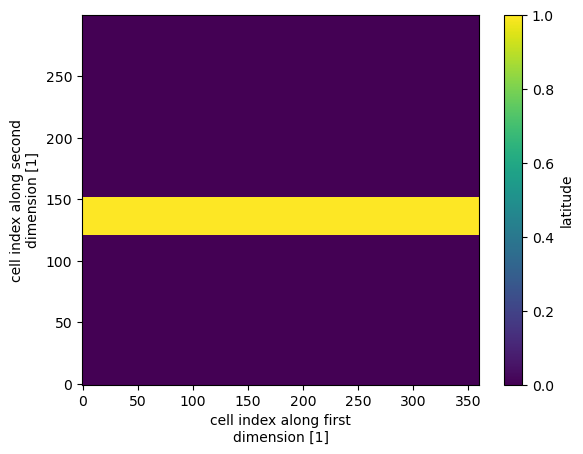

In [30]:
custom_mask.plot()

In [31]:
from functools import partial

In [32]:
def _preprocess(x, mask):
    return x.where(mask, drop=True).sel(lev=slice(0, 350)).resample(time = 'AS-JUN').mean('time')

partial_func = partial(_preprocess, mask=custom_mask)

In [41]:
# def process_model_for_heat_budget(model_identifier, outdir="/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/vo_tropics/"):
#     # Hist
#     var_file_hist = vo_files_hist[model_identifier]
#     ds_var_hist = (
#         xr.open_mfdataset(
#             var_file_hist, use_cftime=True, parallel=True, preprocess=partial_func,
#             chunks=dict(time=3, lev=-1, i=-1, j=-1),
#             data_vars=["vo"], coords="minimal", compat="override", join="override"
#         ).vo
#     )
#     print('done hist loading')

#     # SSP5
#     var_file_ssp = vo_files_ssp5[model_identifier]
#     ds_var_ssp = (
#         xr.open_mfdataset(
#             var_file_ssp, use_cftime=True, parallel=True, preprocess=partial_func,
#             chunks=dict(time=3, lev=-1, i=-1, j=-1),
#             data_vars=["vo"], coords="minimal", compat="override", join="override"
#         ).vo
#     )
#     print('done ssp5 loading')

#     # Lazy concat
#     combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time").resample(time = 'AS-JUN').mean('time')#.load()
#     print('combined')
#     outpath = f"{outdir}/{model_identifier}.zarr"
#     combined.chunk(dict(time=3, lev=-1, i=-1, j=-1)).to_dataset(name='vo').to_zarr(outpath, mode='w')
#     return outpath


def process_model_for_heat_budget(model_identifier, outdir="/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/vo_tropics/"):
    
    # Define a helper function to open and preprocess a single set of files lazily
    def open_and_subset(files):
        # Use chunks suitable for *reading* from netCDF, actual chunking for Zarr happens later
        ds = xr.open_mfdataset(
            files, use_cftime=True, parallel=True, preprocess=partial_func,
            chunks=dict(time=50, lev=-1, i=-1, j=-1), # Larger time chunks for reading might be faster
            data_vars=["vo"], coords="minimal", compat="override", join="override"
        ).vo
        # The preprocess function already applies the initial resampling/subsetting/masking
        return ds

    ds_var_hist = open_and_subset(vo_files_hist[model_identifier])
    ds_var_ssp = open_and_subset(vo_files_ssp5[model_identifier])
    
    # Lazy concat
    # Remove the redundant second resample/mean call from the original code
    combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time") 
    print('combined lazily')

    outpath = f"{outdir}/{model_identifier}.zarr"
    
    # Rechunk for optimal Zarr writing and analysis later
    # Chunking by time=~years is usually good.
    # The .load() operation is the actual computation trigger.
    combined.chunk(dict(time=50, lev=-1, i=-1, j=-1)).to_dataset(name='vo').to_zarr(outpath, mode='w')
    
    return outpath


In [42]:
models_to_process = [(model) for model in vo_files_hist if model in vo_files_ssp5]
models_to_process

['ACCESS-ESM1-5_r27i1p1f',
 'ACCESS-ESM1-5_r10i1p1f',
 'ACCESS-ESM1-5_r31i1p1f',
 'ACCESS-ESM1-5_r9i1p1f',
 'ACCESS-ESM1-5_r5i1p1f',
 'ACCESS-ESM1-5_r26i1p1f',
 'ACCESS-ESM1-5_r11i1p1f',
 'ACCESS-ESM1-5_r8i1p1f',
 'ACCESS-ESM1-5_r30i1p1f',
 'ACCESS-ESM1-5_r4i1p1f',
 'ACCESS-ESM1-5_r25i1p1f',
 'ACCESS-ESM1-5_r29i1p1f',
 'ACCESS-ESM1-5_r33i1p1f',
 'ACCESS-ESM1-5_r12i1p1f',
 'ACCESS-ESM1-5_r7i1p1f',
 'ACCESS-ESM1-5_r24i1p1f',
 'ACCESS-ESM1-5_r28i1p1f',
 'ACCESS-ESM1-5_r32i1p1f',
 'ACCESS-ESM1-5_r13i1p1f',
 'ACCESS-ESM1-5_r6i1p1f',
 'ACCESS-ESM1-5_r40i1p1f',
 'ACCESS-ESM1-5_r23i1p1f',
 'ACCESS-ESM1-5_r39i1p1f',
 'ACCESS-ESM1-5_r1i1p1f',
 'ACCESS-ESM1-5_r18i1p1f',
 'ACCESS-ESM1-5_r14i1p1f',
 'ACCESS-ESM1-5_r35i1p1f',
 'ACCESS-ESM1-5_r22i1p1f',
 'ACCESS-ESM1-5_r38i1p1f',
 'ACCESS-ESM1-5_r19i1p1f',
 'ACCESS-ESM1-5_r15i1p1f',
 'ACCESS-ESM1-5_r34i1p1f',
 'ACCESS-ESM1-5_r21i1p1f',
 'ACCESS-ESM1-5_r3i1p1f',
 'ACCESS-ESM1-5_r37i1p1f',
 'ACCESS-ESM1-5_r16i1p1f',
 'ACCESS-ESM1-5_r20i1p1f',
 'ACCESS-

In [43]:
np.array(models_to_process)

array(['ACCESS-ESM1-5_r27i1p1f', 'ACCESS-ESM1-5_r10i1p1f',
       'ACCESS-ESM1-5_r31i1p1f', 'ACCESS-ESM1-5_r9i1p1f',
       'ACCESS-ESM1-5_r5i1p1f', 'ACCESS-ESM1-5_r26i1p1f',
       'ACCESS-ESM1-5_r11i1p1f', 'ACCESS-ESM1-5_r8i1p1f',
       'ACCESS-ESM1-5_r30i1p1f', 'ACCESS-ESM1-5_r4i1p1f',
       'ACCESS-ESM1-5_r25i1p1f', 'ACCESS-ESM1-5_r29i1p1f',
       'ACCESS-ESM1-5_r33i1p1f', 'ACCESS-ESM1-5_r12i1p1f',
       'ACCESS-ESM1-5_r7i1p1f', 'ACCESS-ESM1-5_r24i1p1f',
       'ACCESS-ESM1-5_r28i1p1f', 'ACCESS-ESM1-5_r32i1p1f',
       'ACCESS-ESM1-5_r13i1p1f', 'ACCESS-ESM1-5_r6i1p1f',
       'ACCESS-ESM1-5_r40i1p1f', 'ACCESS-ESM1-5_r23i1p1f',
       'ACCESS-ESM1-5_r39i1p1f', 'ACCESS-ESM1-5_r1i1p1f',
       'ACCESS-ESM1-5_r18i1p1f', 'ACCESS-ESM1-5_r14i1p1f',
       'ACCESS-ESM1-5_r35i1p1f', 'ACCESS-ESM1-5_r22i1p1f',
       'ACCESS-ESM1-5_r38i1p1f', 'ACCESS-ESM1-5_r19i1p1f',
       'ACCESS-ESM1-5_r15i1p1f', 'ACCESS-ESM1-5_r34i1p1f',
       'ACCESS-ESM1-5_r21i1p1f', 'ACCESS-ESM1-5_r3i1p1f',
     

In [47]:
models_to_process = ['ACCESS-ESM1-5_r10i1p1f', 'ACCESS-ESM1-5_r20i1p1f', 'ACCESS-ESM1-5_r30i1p1f']

In [48]:
# res_arr = []

# for i, model_identifier in enumerate(models_to_process):
#     _, out = process_model(models_to_process[i])
#     res_arr.append((model_identifier, out))
#     print(f'Completed {i+1}')

In [49]:
# Submit all processing tasks to the Dask client immediately
futures = []
for model in models_to_process:
    future = client.submit(process_model_for_heat_budget, model)
    futures.append(future)

print(f"Submitted {len(futures)} tasks to the Dask cluster.")

# Use as_completed to monitor and process results as they finish
for i, future in enumerate(as_completed(futures)):
    try:
        zarr_path = future.result()
        print(f"Completed {i+1}/{len(models_to_process)} -> saved to {zarr_path}")
    except Exception as e:
        print(f"Task failed for one model: {e}")

print("All models processed.")

Submitted 3 tasks to the Dask cluster.
Task failed for one model: Attempted to run task 'process_model_for_heat_budget-63c8077372aca0131a34ee33cd7063f0' on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:44107. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.
Task failed for one model: Attempted to run task 'process_model_for_heat_budget-ff755114758021daeed9162e8eb977d2' on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:40221. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.
Task failed for one model: Attempted to run task 'process_model_for_heat_budget-066ea95f43a574ee56b20304643c6cfb' on 4 different workers, but

In [38]:
# res_arr = []
# for i, model in enumerate(models_to_process):
#     zarr_path = process_model_for_heat_budget(model)
#     res_arr.append(zarr_path)
#     print(f"Completed {i+1}/{len(models_to_process)} -> saved to {zarr_path}", end="\r")

In [ ]:
# import glob
# files = glob.glob('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao/*.zarr')

# datasets = [xr.open_zarr(f) for f in files]
# # Combine lazily along new model dimension
# combined = xr.concat([ds['thetao'] for ds in datasets], dim="model")

In [ ]:
# combined.sel(time = slice('1850', '1900')).mean(('time', 'j', 'model')).plot(cmap=cmocean.cm.balance, vmin=10, vmax=30)
# combined.sel(time = slice('1850', '1900')).mean(('time', 'j', 'model')).plot.contour(cmap=cmocean.cm.balance, levels=[20])
# plt.gca().invert_yaxis()

### run for ekman velocity

In [15]:
from dask.distributed import Client

In [16]:
client = Client(threads_per_worker=2)
# client.amm.start()
client

2025-10-08 16:45:05,540 [INFO]: scheduler.py(__init__:1766) >> State start
2025-10-08 16:45:05,540 [INFO]: scheduler.py(__init__:1766) >> State start
2025-10-08 16:45:05,562 [INFO]: scheduler.py(start_unsafe:4282) >>   Scheduler at:     tcp://127.0.0.1:45835
2025-10-08 16:45:05,562 [INFO]: scheduler.py(start_unsafe:4282) >>   Scheduler at:     tcp://127.0.0.1:45835
2025-10-08 16:45:05,564 [INFO]: scheduler.py(start_unsafe:4297) >>   dashboard at:  http://127.0.0.1:39761/status
2025-10-08 16:45:05,564 [INFO]: scheduler.py(start_unsafe:4297) >>   dashboard at:  http://127.0.0.1:39761/status
2025-10-08 16:45:05,565 [INFO]: scheduler.py(register_worker_plugin:8177) >> Registering Worker plugin shuffle
2025-10-08 16:45:05,565 [INFO]: scheduler.py(register_worker_plugin:8177) >> Registering Worker plugin shuffle
2025-10-08 16:45:05,678 [INFO]: nanny.py(start_unsafe:368) >>         Start Nanny at: 'tcp://127.0.0.1:33955'
2025-10-08 16:45:05,678 [INFO]: nanny.py(start_unsafe:368) >>         St

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:39761/status,
Dashboard: http://127.0.0.1:39761/status,Workers: 7
Total threads: 14,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45835,Workers: 0
Dashboard: http://127.0.0.1:39761/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37889,Total threads: 2
Dashboard: http://127.0.0.1:33797/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:33955,


2025-10-08 16:45:24,353 [INFO]: scheduler.py(add_client:5959) >> Receive client connection: Client-worker-fc525143-a409-11f0-9ce9-000003b9fe80
2025-10-08 16:45:24,353 [INFO]: scheduler.py(add_client:5959) >> Receive client connection: Client-worker-fc525143-a409-11f0-9ce9-000003b9fe80
2025-10-08 16:45:24,356 [INFO]: core.py(handle_stream:883) >> Starting established connection to tcp://127.0.0.1:40486
2025-10-08 16:45:24,356 [INFO]: core.py(handle_stream:883) >> Starting established connection to tcp://127.0.0.1:40486
2025-10-08 16:45:27,697 [INFO]: scheduler.py(add_client:5959) >> Receive client connection: Client-worker-fe51cbc4-a409-11f0-9ccf-000003b9fe80
2025-10-08 16:45:27,697 [INFO]: scheduler.py(add_client:5959) >> Receive client connection: Client-worker-fe51cbc4-a409-11f0-9ccf-000003b9fe80
2025-10-08 16:45:27,699 [INFO]: core.py(handle_stream:883) >> Starting established connection to tcp://127.0.0.1:35900
2025-10-08 16:45:27,699 [INFO]: core.py(handle_stream:883) >> Starting 

In [17]:
sample = xr.open_mfdataset(wo_files_hist['ACCESS-ESM1-5_r10i1p1f'])
sample

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


<xarray.Dataset> Size: 56GB
Dimensions:             (time: 1980, bnds: 2, lev: 50, j: 300, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 20...
  * lev                 (lev) float64 400B 10.0 20.0 30.0 ... 5.665e+03 6e+03
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude           (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lev_bnds            (time, lev, bnds) float64 2MB dask.array<chunksize=(120, 50, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 7GB dask.array<chunksize=(120, 300, 360, 2), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 7GB dask.array<chunksize=(120, 300, 360, 2), meta=np.ndarray>
    wo                  (time, lev, j, i) float32 43GB dask.array<chunksize=(1, 25, 150, 180), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    contact:                access_csiro@csiro.au
    ...                     ...
    variable_id:            wo
    variant_label:          r10i1p1f1
    version:                v20220426
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/4dbdf105-53a8-43db-85a6-959197e2b229

In [18]:
# import xesmf as xe

In [19]:
# regridder = xe.Regridder(sample, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [20]:
# # Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
# lat = sample['latitude']  # shape: (i, j)
# lon = sample['longitude']

# # Define your region
# lat_min, lat_max = -5, 5
# lon_min, lon_max = 100, 300

# # Build a mask for where lat/lon fall within the box
# # custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
# #               (lon >= lon_min) & (lon <= lon_max))

# custom_mask = ((lat >= lat_min) & (lat <= lat_max))
# custom_mask

In [21]:
# custom_mask.plot()

In [22]:
from functools import partial

In [23]:
def _preprocess(x):
    return x.sel(lev=slice(0, 100)).mean('lev')#.resample(time = 'AS-JUN').mean('time')

# partial_func = partial(_preprocess, mask=custom_mask)

In [24]:
def process_model_for_wo(model_identifier, outdir="/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/wo/"):
    # Hist
    var_file_hist = wo_files_hist[model_identifier]
    ds_var_hist = (
        xr.open_mfdataset(
            var_file_hist, use_cftime=True, parallel=True, preprocess=_preprocess,
            chunks=dict(time=3, lev=-1, i=-1, j=-1),
            data_vars=["wo"], coords="minimal", compat="override", join="override"
        ).wo
    )

    # SSP5
    var_file_ssp = wo_files_ssp5[model_identifier]
    ds_var_ssp = (
        xr.open_mfdataset(
            var_file_ssp, use_cftime=True, parallel=True, preprocess=_preprocess,
            chunks=dict(time=3, lev=-1, i=-1, j=-1),
            data_vars=["wo"], coords="minimal", compat="override", join="override"
        ).wo
    )

    # Lazy concat
    combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time").resample(time = 'AS-JUN').mean('time')#.load()
    outpath = f"{outdir}/{model_identifier}.zarr"
    combined.to_dataset(name='wo').to_zarr(outpath, mode='w')
    return outpath

In [25]:
models_to_process = [(model) for model in wo_files_hist if model in wo_files_ssp5]
models_to_process

['ACCESS-ESM1-5_r27i1p1f',
 'ACCESS-ESM1-5_r10i1p1f',
 'ACCESS-ESM1-5_r31i1p1f',
 'ACCESS-ESM1-5_r9i1p1f',
 'ACCESS-ESM1-5_r5i1p1f',
 'ACCESS-ESM1-5_r26i1p1f',
 'ACCESS-ESM1-5_r11i1p1f',
 'ACCESS-ESM1-5_r8i1p1f',
 'ACCESS-ESM1-5_r30i1p1f',
 'ACCESS-ESM1-5_r4i1p1f',
 'ACCESS-ESM1-5_r25i1p1f',
 'ACCESS-ESM1-5_r29i1p1f',
 'ACCESS-ESM1-5_r33i1p1f',
 'ACCESS-ESM1-5_r12i1p1f',
 'ACCESS-ESM1-5_r7i1p1f',
 'ACCESS-ESM1-5_r24i1p1f',
 'ACCESS-ESM1-5_r28i1p1f',
 'ACCESS-ESM1-5_r32i1p1f',
 'ACCESS-ESM1-5_r13i1p1f',
 'ACCESS-ESM1-5_r6i1p1f',
 'ACCESS-ESM1-5_r40i1p1f',
 'ACCESS-ESM1-5_r23i1p1f',
 'ACCESS-ESM1-5_r39i1p1f',
 'ACCESS-ESM1-5_r1i1p1f',
 'ACCESS-ESM1-5_r18i1p1f',
 'ACCESS-ESM1-5_r14i1p1f',
 'ACCESS-ESM1-5_r35i1p1f',
 'ACCESS-ESM1-5_r22i1p1f',
 'ACCESS-ESM1-5_r38i1p1f',
 'ACCESS-ESM1-5_r19i1p1f',
 'ACCESS-ESM1-5_r15i1p1f',
 'ACCESS-ESM1-5_r34i1p1f',
 'ACCESS-ESM1-5_r21i1p1f',
 'ACCESS-ESM1-5_r3i1p1f',
 'ACCESS-ESM1-5_r37i1p1f',
 'ACCESS-ESM1-5_r16i1p1f',
 'ACCESS-ESM1-5_r20i1p1f',
 'ACCESS-

In [26]:
# res_arr = []

# for i, model_identifier in enumerate(models_to_process):
#     _, out = process_model(models_to_process[i])
#     res_arr.append((model_identifier, out))
#     print(f'Completed {i+1}')

In [27]:
res_arr = []
for i, model in enumerate(models_to_process):
    zarr_path = process_model_for_wo(model)
    res_arr.append(zarr_path)
    print(f"Completed {i+1}/{len(models_to_process)} -> saved to {zarr_path}", end="\r")

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


Exception ignored in: <function CachingFileManager.__del__ at 0x7efcd1e8ad40>
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7efcd1e8ad40>
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__

[1759905032.355579] [gadi-cpu-bdw-0047:1875177:1]           debug.c:1290 UCX  WARN  ucs_debug_disable_signal: signal 8 was not set in ucs
[1759905032.355573] [gadi-cpu-bdw-0047:1875177:0]        spinlock.c:29   UCX  WARN  ucs_recursive_spinlock_destroy() failed: busy


[gadi-cpu-bdw-0047:1875177:1:1876499] Caught signal 11 (Segmentation fault: address not mapped to object at address 0x4)
[gadi-cpu-bdw-0047:1875177:0:1876492] Caught signal 11 (Segmentation fault: address not mapped to object at address 0x4)
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .debug_ranges section.
BFD: Dwarf Error: Can't find .

In [ ]:
# import glob
# files = glob.glob('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao/*.zarr')

# datasets = [xr.open_zarr(f) for f in files]
# # Combine lazily along new model dimension
# combined = xr.concat([ds['thetao'] for ds in datasets], dim="model")

### cross-section and side view thetao values

In [ ]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = sample['latitude']  # shape: (i, j)
lon = sample['longitude']

# Define your region
lat_min, lat_max = -80, -40
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
# custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
#               (lon >= lon_min) & (lon <= lon_max))

custom_mask = ((lat >= lat_min) & (lat <= lat_max))

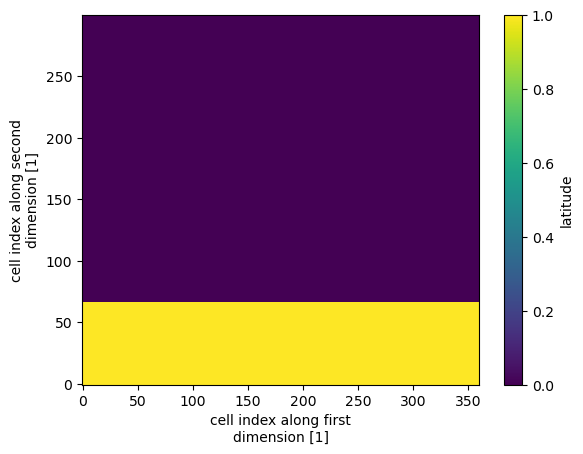

In [ ]:
custom_mask.plot()

In [ ]:
from functools import partial

In [ ]:
def _preprocess(x, mask):
    return x.where(mask, drop=True).sel(lev=slice(0, 2000))#.resample(time = 'AS-JUN').mean('time')

partial_func = partial(_preprocess, mask=custom_mask)

In [ ]:
model_identifier = models_to_process[0]
model_identifier

'ACCESS-ESM1-5_r10i1p1f'

In [ ]:

var_file_hist = thetao_files_hist[model_identifier]
ds_var_hist = (
    xr.open_mfdataset(
        var_file_hist, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=-1),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)

In [ ]:
ds_var_hist

<xarray.DataArray 'thetao' (time: 1980, lev: 36, j: 67, i: 360)>
dask.array<concatenate, shape=(1980, 36, 67, 360), dtype=float32, chunksize=(120, 36, 67, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lev        (lev) float64 5.0 15.0 25.0 ... 1.623e+03 1.802e+03 1.985e+03
  * j          (j) int32 0 1 2 3 4 5 6 7 8 9 ... 57 58 59 60 61 62 63 64 65 66
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 -77.88 -77.88 -77.88 ... -40.38 -40.38 -40.38
    longitude  (j, i) float64 80.5 81.5 82.5 83.5 84.5 ... 76.5 77.5 78.5 79.5
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        Diagnostic should be contributed even for models using co...
    units:          degC
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello
    history:        2020-07-30T04:35:12Z altered by CMOR: replaced missing va...

In [ ]:

# SSP5
var_file_ssp = thetao_files_ssp5[model_identifier]
ds_var_ssp = (
    xr.open_mfdataset(
        var_file_ssp, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=-1),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)


In [ ]:
# Lazy concat
combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time")#.load()

In [ ]:
thetao_so = combined.resample(time = 'AS-JUN').mean('time').load()

In [ ]:
thetao_so.to_dataset(name='thetao').to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao_so/thetao_so_trans_r10.nc')

In [ ]:
# # Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
# lat = sample['latitude']  # shape: (i, j)
# lon = sample['longitude']

# # Define your region
# lat_min, lat_max = -80, -40
# lon_min, lon_max = 100, 300

# # Build a mask for where lat/lon fall within the box
# # custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
# #               (lon >= lon_min) & (lon <= lon_max))

# custom_mask = ((lat >= lat_min) & (lat <= lat_max))

In [ ]:
# custom_mask.plot()

In [ ]:
from functools import partial

In [ ]:
def _preprocess(x, mask):
    return x.sel(lev=slice(0, 2000))#.resample(time = 'AS-JUN').mean('time')

partial_func = partial(_preprocess, mask=custom_mask)

In [ ]:
model_identifier = models_to_process[0]
model_identifier

'ACCESS-ESM1-5_r10i1p1f'

In [ ]:

var_file_hist = thetao_files_hist[model_identifier]
ds_var_hist = (
    xr.open_mfdataset(
        var_file_hist, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=90),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)

In [ ]:
ds_var_hist

<xarray.DataArray 'thetao' (time: 1980, lev: 36, j: 300, i: 360)>
dask.array<concatenate, shape=(1980, 36, 300, 360), dtype=float32, chunksize=(120, 36, 90, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lev        (lev) float64 5.0 15.0 25.0 ... 1.623e+03 1.802e+03 1.985e+03
  * j          (j) int32 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        Diagnostic should be contributed even for models using co...
    units:          degC
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello
    history:        2020-07-30T04:35:12Z altered by CMOR: replaced missing va...

In [ ]:

# SSP5
var_file_ssp = thetao_files_ssp5[model_identifier]
ds_var_ssp = (
    xr.open_mfdataset(
        var_file_ssp, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=-1),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)


In [ ]:
# Lazy concat
combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time")#.load()

In [ ]:
thetao_zonal = combined.resample(time = 'AS-JUN').mean('time').mean('i').load()

In [ ]:
thetao_zonal.to_dataset(name='thetao').to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao_zonal/thetao_zonal_trans_r10.nc')

In [ ]:
thetao_zonal

<xarray.DataArray 'thetao' (time: 252, lev: 36, j: 300)>
array([[[        nan, -1.6154453 , -1.5342916 , ..., -1.7129434 ,
         -1.7106678 , -1.7059964 ],
        [        nan, -1.6288234 , -1.5695149 , ..., -1.7141683 ,
         -1.7118527 , -1.7075018 ],
        [        nan, -1.656011  , -1.6110792 , ..., -1.7153057 ,
         -1.7129503 , -1.7088045 ],
        ...,
        [        nan,         nan,         nan, ..., -0.585654  ,
         -0.5890004 , -0.59194064],
        [        nan,         nan,         nan, ..., -0.6074667 ,
         -0.611016  , -0.6116457 ],
        [        nan,         nan,         nan, ..., -0.63249403,
         -0.6339609 , -0.6359188 ]],

       [[        nan, -1.452658  , -1.4985379 , ..., -1.2702024 ,
         -1.2799987 , -1.2656325 ],
        [        nan, -1.5111833 , -1.5612712 , ..., -1.3715655 ,
         -1.3739002 , -1.3603352 ],
        [        nan, -1.5757155 , -1.6230018 , ..., -1.4882315 ,
         -1.4849086 , -1.4740585 ],
...
        [        nan,         nan,         nan, ...,  0.18216121,
          0.18432878,  0.18561853],
        [        nan,         nan,         nan, ..., -0.0599592 ,
         -0.05969981, -0.05086387],
        [        nan,         nan,         nan, ..., -0.23267382,
         -0.23397723, -0.2283296 ]],

       [[        nan, -1.4619166 , -1.4834775 , ...,  4.6795545 ,
          4.64628   ,  4.666546  ],
        [        nan, -1.5926588 , -1.6349182 , ...,  3.8124697 ,
          3.766077  ,  3.778912  ],
        [        nan, -1.6980983 , -1.7313137 , ...,  2.5212412 ,
          2.4624329 ,  2.4559472 ],
        ...,
        [        nan,         nan,         nan, ...,  0.17890723,
          0.18349075,  0.1845912 ],
        [        nan,         nan,         nan, ..., -0.06511056,
         -0.06351776, -0.05490663],
        [        nan,         nan,         nan, ..., -0.2373814 ,
         -0.23800981, -0.23462614]]], dtype=float32)
Coordinates:
  * lev      (lev) float64 5.0 15.0 25.0 35.0 ... 1.623e+03 1.802e+03 1.985e+03
  * j        (j) int32 0 1 2 3 4 5 6 7 8 ... 291 292 293 294 295 296 297 298 299
  * time     (time) object 1849-06-01 00:00:00 ... 2100-06-01 00:00:00